# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [5]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [ ]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- LIST giá trị Metabase (network giờ là Field Filter multi-select)

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

# [CẬP NHẬT 2026-09-26] Card Metabase id=81 đã bỏ date_from/date_to, thay bằng
# Field Filter "cohort_date" (type date/all-options) — dùng chung 1 khoảng ngày,
# format START~END (Metabase) khớp adjust_date_period format START:END (Adjust).
metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

## 1. Lấy dữ liệu Metabase

In [ ]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

# [CẬP NHẬT 2026-09-26] Card id=81 sửa lại phía owner (2026-09-24): "network",
# "game", "platform" giờ là Field Filter multi-select thật (không còn Plain
# Variable scalar) — PHẢI truyền value dạng LIST dù chỉ chọn 1 giá trị, nếu
# không Organic/game khác có thể lọt vào (đã xác nhận qua request thật tới
# API, xem ghi chú trong config.py cạnh NETWORK_OPTIONS).
parameters = mb.build_parameters(
    game["metabase_card_id"],
    cohort_date=metabase_date_range,       # "2026-08-01~2026-09-17" — Field Filter date/all-options
    network=metabase_network_value,        # list, VD ["APPLOVIN"] hoặc ["APPLOVIN","UNITY"]
    game=[game["metabase_game"]],          # list, VD ["Game B"] — không còn scalar
    platform=[game["metabase_platform"]],  # list, VD ["IOS"] — không còn scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [8]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 191
Totals: {'installs': 55468.0, 'network_cost': 228245.7072, 'roas_cal_d0': 0.062, 'roas_cal_d3': 0.1974, 'roas_cal_d7': 0.2936, 'roas_cal_d14': 0.3984, 'roas_cal_d28': 0.5203, 'ad_revenue_total_cal_d0': 13569.6583, 'ad_revenue_total_cal_d3': 43185.6647, 'ad_revenue_total_cal_d7': 62058.4568, 'ad_revenue_total_cal_d14': 78765.3911, 'ad_revenue_total_cal_d28': 83154.6713, 'revenue_total_cal_d0': 585.733, 'revenue_total_cal_d3': 1881.319, 'revenue_total_cal_d7': 3121.081, 'revenue_total_cal_d14': 4491.495, 'revenue_total_cal_d28': 6139.993}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-08-01,Unity,CDS iOS - D28 AdROAS - 260616,1441,5450.4439,0.0593,0.1644,0.2565,0.3673,0.5052,297.4966,861.2013,1330.1733,1851.8501,2443.5207,25.709,34.693,67.811,150.352,309.985
1,2026-08-23,Unity,CDS iOS - D28 AdROAS - 260616,1175,2590.8808,0.0529,0.1497,0.2309,0.3292,0.4322,136.9447,384.9746,595.5702,847.3681,1114.341,0.0,2.787,2.787,5.493,5.493
2,2026-08-26,Unity,CDS iOS - D28 AdROAS - 260616,1118,1827.2974,0.0403,0.1552,0.2741,0.3945,0.0,73.6718,283.6506,500.8348,720.8123,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-08-07,Unity,CDS iOS - D28 AdROAS - 260616,1031,2863.3069,0.0376,0.1557,0.2437,0.3287,0.4048,107.5817,442.786,676.623,919.8763,1137.7973,0.0,3.087,21.152,21.152,21.152
4,2026-08-18,Unity,CDS iOS - D28 AdROAS - 260616,1017,2103.1087,0.0442,0.2058,0.3111,0.4387,0.5916,93.0557,426.6825,646.3059,914.6473,1229.4303,0.0,6.048,8.035,8.035,14.725


## 3. Normalize + loại ngày lỗi + Merge

In [9]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 191 dòng
Chỉ có ở Metabase: 0 dòng
Chỉ có ở Adjust: 0 dòng


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [10]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-17
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 3247 dòng (= 191 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 636


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-01,APPLOVIN,CDS iOS - D28 AdROAS - 260212,AD_REVENUE_D0,47,False,137.117677,137.1177,-0.000023,1.000000,-0.0000,OK
1,2026-08-01,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,AD_REVENUE_D0,47,False,383.621763,383.6218,-0.000037,1.000000,-0.0000,OK
2,2026-08-01,UNITY,CDS iOS - D28 AdROAS - 260616,AD_REVENUE_D0,47,False,296.302016,297.4966,-1.194584,0.995985,-0.4015,OK
3,2026-08-01,UNITY,CDS iOS - D28 BLDROAS - 260723,AD_REVENUE_D0,47,False,50.639149,50.6391,0.000049,1.000001,0.0001,OK
4,2026-08-01,UNITY,CDS iOS - D7 AdROAS - 260616,AD_REVENUE_D0,47,False,6.819855,7.6346,-0.814745,0.893283,-10.6717,Discrepancy
5,2026-08-01,UNITY,CDS iOS - D7 BLDROAS - 260723,AD_REVENUE_D0,47,False,22.771224,22.7712,0.000024,1.000001,0.0001,OK
6,2026-08-01,APPLOVIN,CDS iOS - D28 AdROAS - 260212,AD_REVENUE_D14,47,False,1099.444131,1101.9164,-2.472269,0.997756,-0.2244,OK
7,2026-08-01,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,AD_REVENUE_D14,47,False,2223.208749,2225.8028,-2.594051,0.998835,-0.1165,OK
8,2026-08-01,UNITY,CDS iOS - D28 AdROAS - 260616,AD_REVENUE_D14,47,False,1833.840408,1851.8501,-18.009692,0.990275,-0.9725,OK
9,2026-08-01,UNITY,CDS iOS - D28 BLDROAS - 260723,AD_REVENUE_D14,47,False,358.137486,364.0924,-5.954914,0.983644,-1.6356,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [11]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                           campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
      CDS iOS - D28 AdROAS - 260212         ROAS_D0       48         0.0004      0.9956                 0.4670                   0.0364                1.0772           2.0833
      CDS iOS - D28 AdROAS - 260212         ROAS_D3       45         0.0010      0.9951                 0.4966                   0.0122                1.1882           2.2222
      CDS iOS - D28 AdROAS - 260212         ROAS_D7       41         0.0010      0.9964                 0.3590                   0.0133                0.8004           0.0000
      CDS iOS - D28 AdROAS - 260212        ROAS_D14       34         0.0016      0.9957                 0.4341                   0.0456                1.5043           0.0000
      CDS iOS - D28 AdROAS - 260212        ROAS_D28       20         0.0037      0.9915  

In [12]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [13]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
2089,2026-09-01,UNITY,CDS iOS - D28 BLDROAS - 260723,AD_REVENUE_D3,63.109994,74.3665,-11.256506,-15.1365
2137,2026-09-01,UNITY,CDS iOS - D28 BLDROAS - 260723,ROAS_D3,0.164677,0.1940,-0.029323,-15.1149
2079,2026-09-01,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,AD_REVENUE_D14,136.863068,158.5509,-21.687832,-13.6788
2127,2026-09-01,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,ROAS_D14,0.424028,0.4912,-0.067172,-13.6752
2141,2026-09-01,UNITY,CDS iOS - D28 BLDROAS - 260723,ROAS_D7,0.228016,0.2574,-0.029384,-11.4157
2093,2026-09-01,UNITY,CDS iOS - D28 BLDROAS - 260723,AD_REVENUE_D7,87.383675,98.6401,-11.256425,-11.4116
76,2026-08-01,UNITY,CDS iOS - D7 AdROAS - 260616,ROAS_D0,0.080288,0.0899,-0.009612,-10.6913
4,2026-08-01,UNITY,CDS iOS - D7 AdROAS - 260616,AD_REVENUE_D0,6.819855,7.6346,-0.814745,-10.6717
1131,2026-08-18,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,AD_REVENUE_D28,1409.636096,1558.1593,-148.523204,-9.5320
1179,2026-08-18,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,ROAS_D28,0.685813,0.7560,-0.070187,-9.2840



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
731,2026-08-12,APPLOVIN,CDS iOS - D28 AdROAS - 260212,AD_REVENUE_D0,24.321575,26.3582,-2.036625,-7.7267
767,2026-08-12,APPLOVIN,CDS iOS - D28 AdROAS - 260212,ROAS_D0,0.061122,0.0662,-0.005078,-7.6708
3018,2026-09-14,APPLOVIN,CDS iOS - D28 AdROAS - 260212,ROAS_D3,0.163452,0.1748,-0.011348,-6.4919
2970,2026-09-14,APPLOVIN,CDS iOS - D28 AdROAS - 260212,AD_REVENUE_D3,23.818751,25.4719,-1.653149,-6.4901
2496,2026-09-07,UNITY,CDS iOS - D28 AdROAS - 260616,AD_REVENUE_D3,171.839646,189.2963,-17.456654,-9.2219
2544,2026-09-07,UNITY,CDS iOS - D28 AdROAS - 260616,ROAS_D3,0.239665,0.2640,-0.024335,-9.2179
2500,2026-09-07,UNITY,CDS iOS - D28 AdROAS - 260616,AD_REVENUE_D7,251.795284,270.9131,-19.117816,-7.0568
2548,2026-09-07,UNITY,CDS iOS - D28 AdROAS - 260616,ROAS_D7,0.363423,0.3901,-0.026677,-6.8385
2020,2026-08-31,UNITY,CDS iOS - D28 AdROAS - 260616,AD_REVENUE_D3,195.819961,208.3567,-12.536739,-6.0170
2079,2026-09-01,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,AD_REVENUE_D14,136.863068,158.5509,-21.687832,-13.6788


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [14]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_b_ios


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  13543.819912    13569.6583 190 -1.904130e-01
    AD_REVENUE_D3  42105.353944    42311.4171 178 -4.870155e-01
    AD_REVENUE_D7  60005.224662    60376.5524 162 -6.150198e-01
   AD_REVENUE_D14  76094.321097    76631.6573 134 -7.011935e-01
   AD_REVENUE_D28  72761.516192    73428.7848  78 -9.087289e-01
   IAP_REVENUE_D0    585.733000      585.7330  55  0.000000e+00
   IAP_REVENUE_D3   1846.333000     1846.3330  88  0.000000e+00
   IAP_REVENUE_D7   3101.179000     3101.1790 102  0.000000e+00
  IAP_REVENUE_D14   4442.653000     4442.6530  95  0.000000e+00
  IAP_REVENUE_D28   4931.255000     4931.2550  63  0.000000e+00
             COST 228245.708014   228245.7077 191  1.375710e-07
         INSTALLS  55424.000000    55468.0000 191 -7.932502e-02
 TOTAL_REVENUE_D0   7681.916598     7693.2986  55 -1.479470e-01
 TOTAL_REVENUE_D3  32393.553836    32510.3658  88 -3

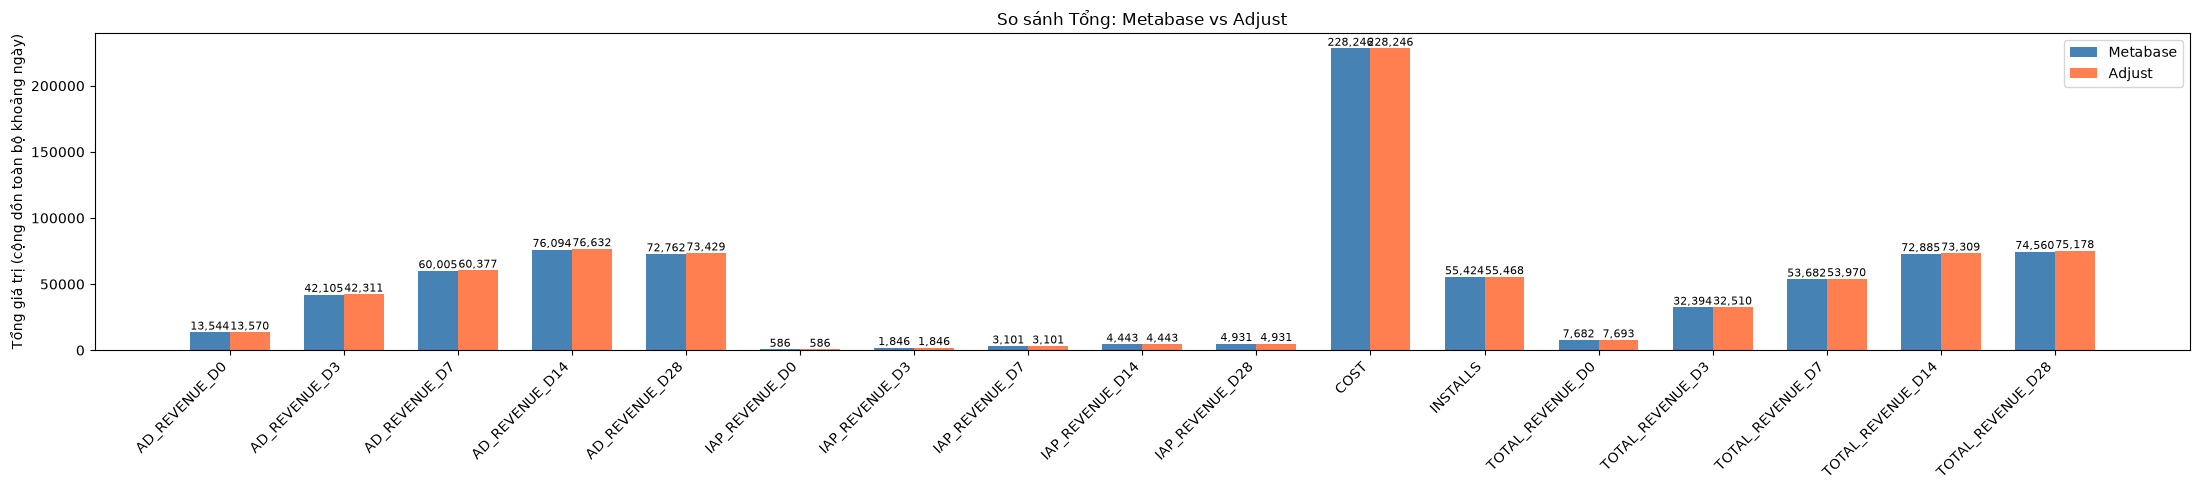

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_b_ios\reconciliation_totals_comparison.csv


In [15]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [16]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [17]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 7
                                     n_days  first_date   last_date
campaign                                                           
CDS iOS - D28 AdROAS - 260212            48  2026-08-01  2026-09-17
CDS iOS - D28 AdROAS - 260616            48  2026-08-01  2026-09-17
CDS iOS - D28 BLDROAS - 260625           48  2026-08-01  2026-09-17
CDS iOS - D28 BLDROAS - 260723           41  2026-08-01  2026-09-17
CDS iOS - D7 BLDROAS - 260723             3  2026-08-01  2026-08-03
CDS iOS - D7 AdROAS - 260616              2  2026-08-01  2026-08-02
CDS iOS - D28 AdROAS - 260916 - CPM       1  2026-09-17  2026-09-17


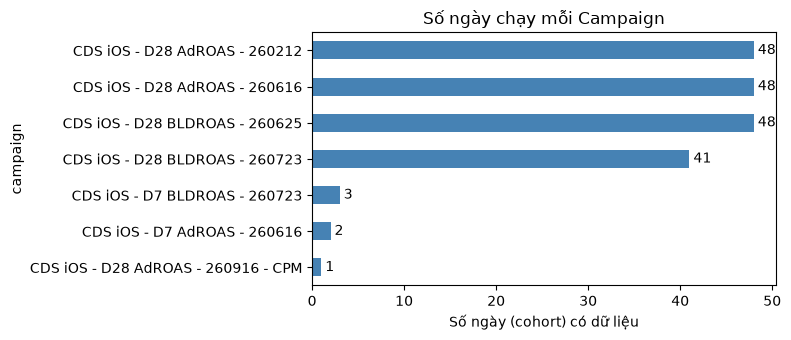

In [18]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

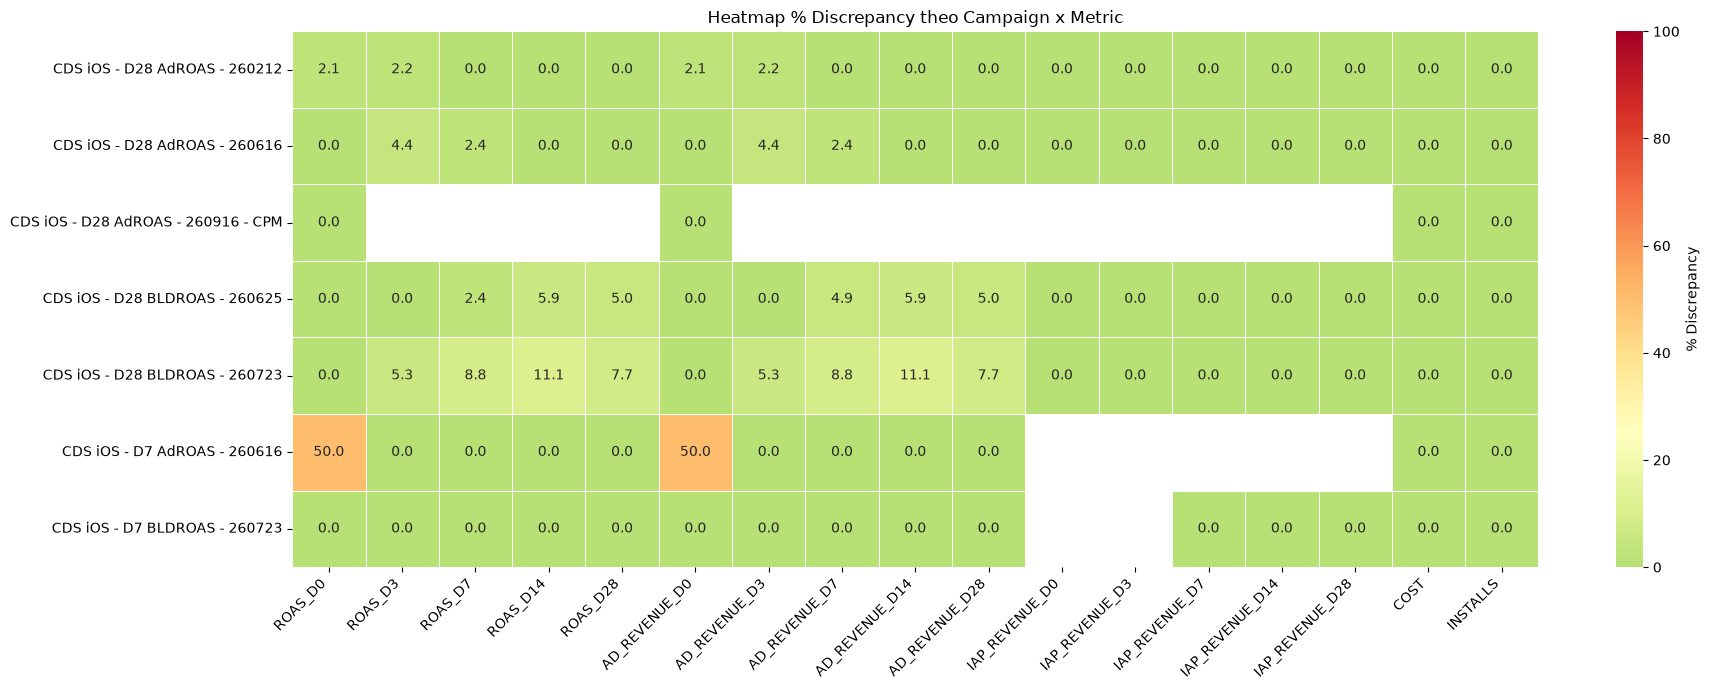

In [19]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

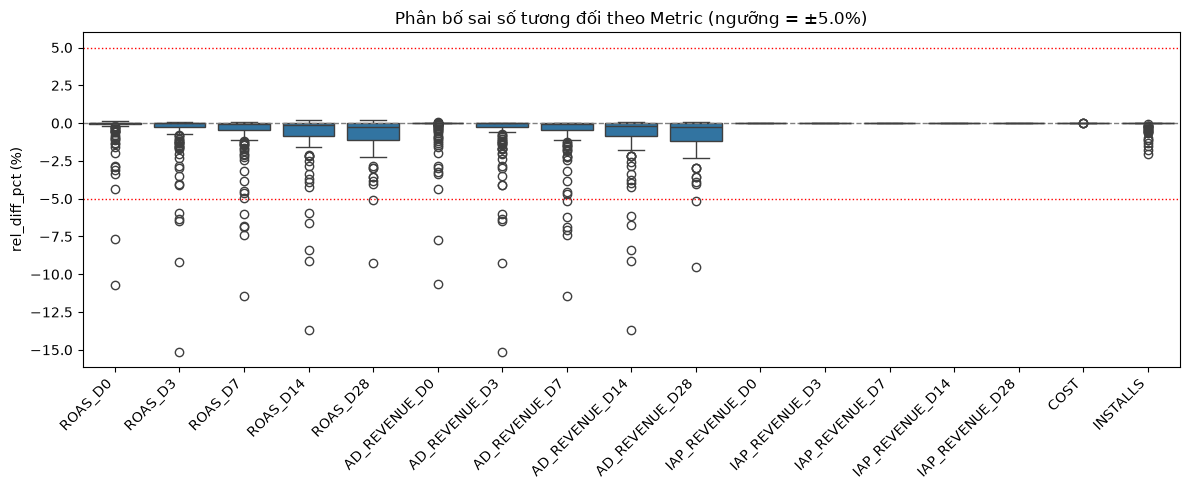

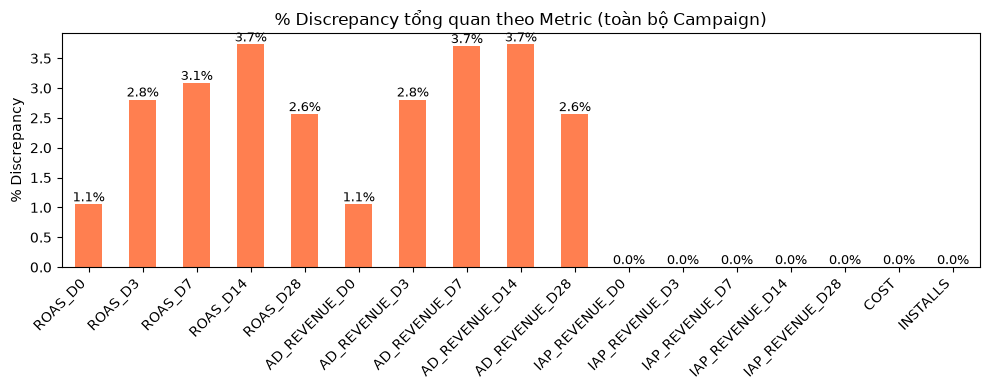

In [20]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

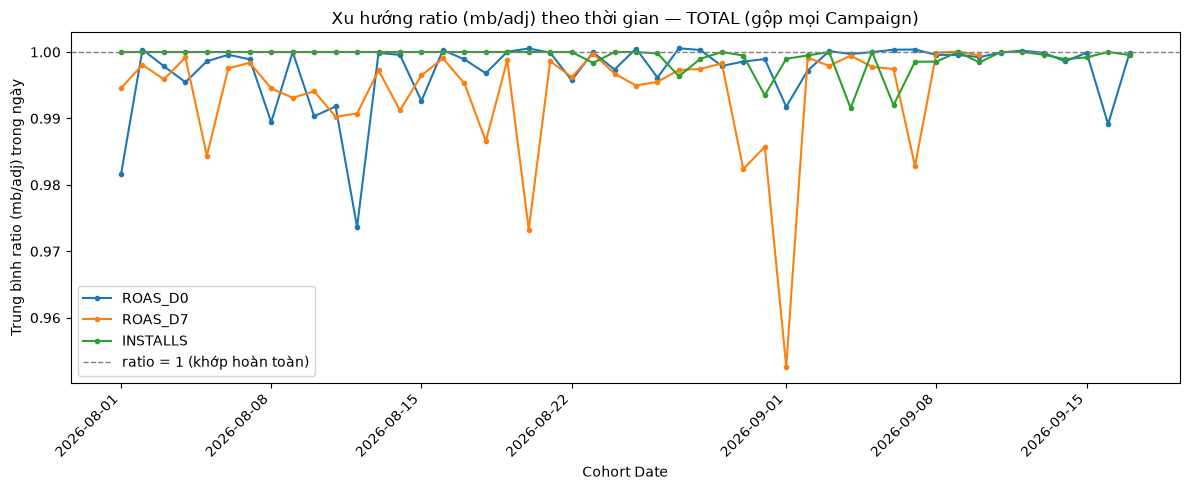

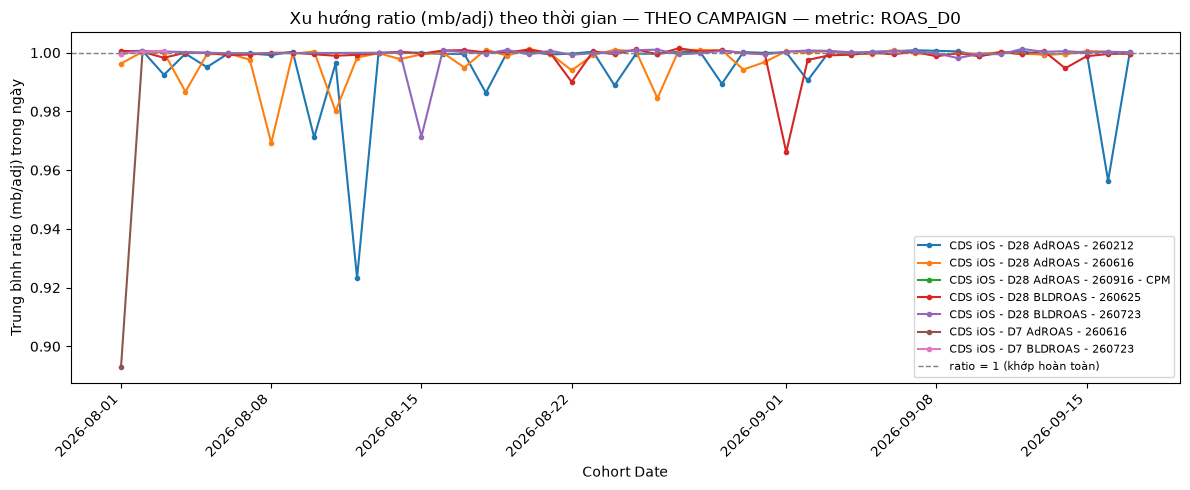

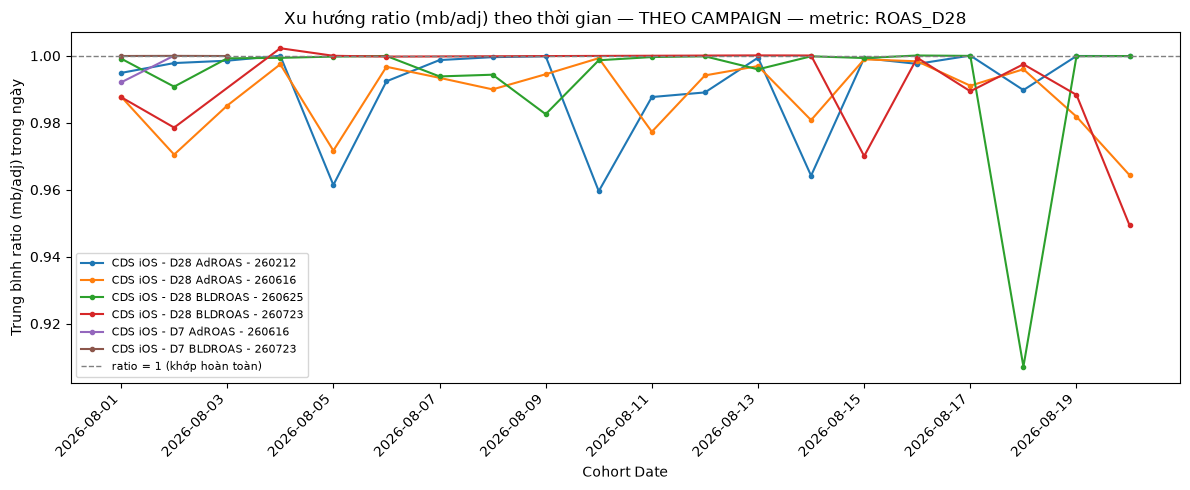

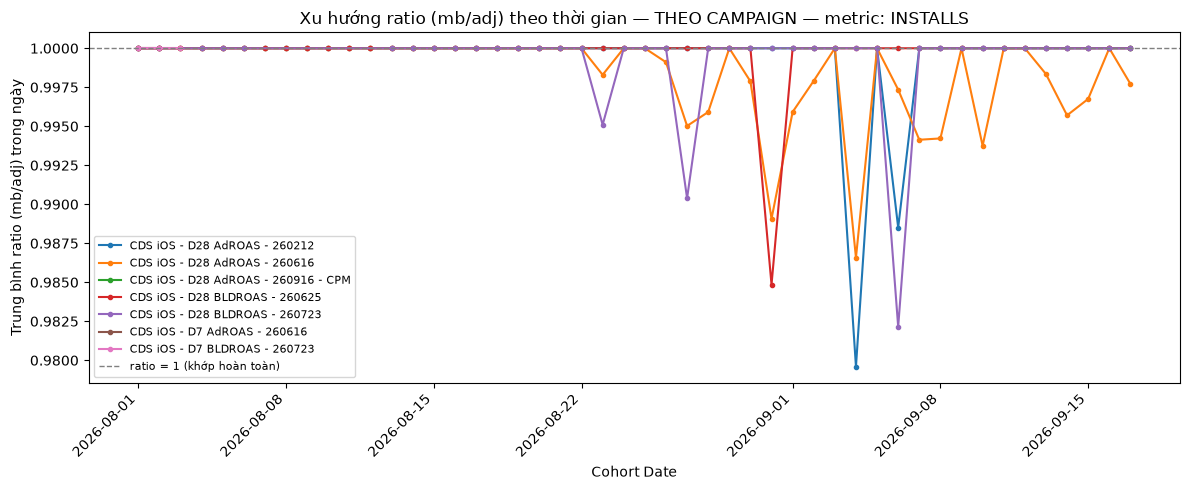

In [21]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

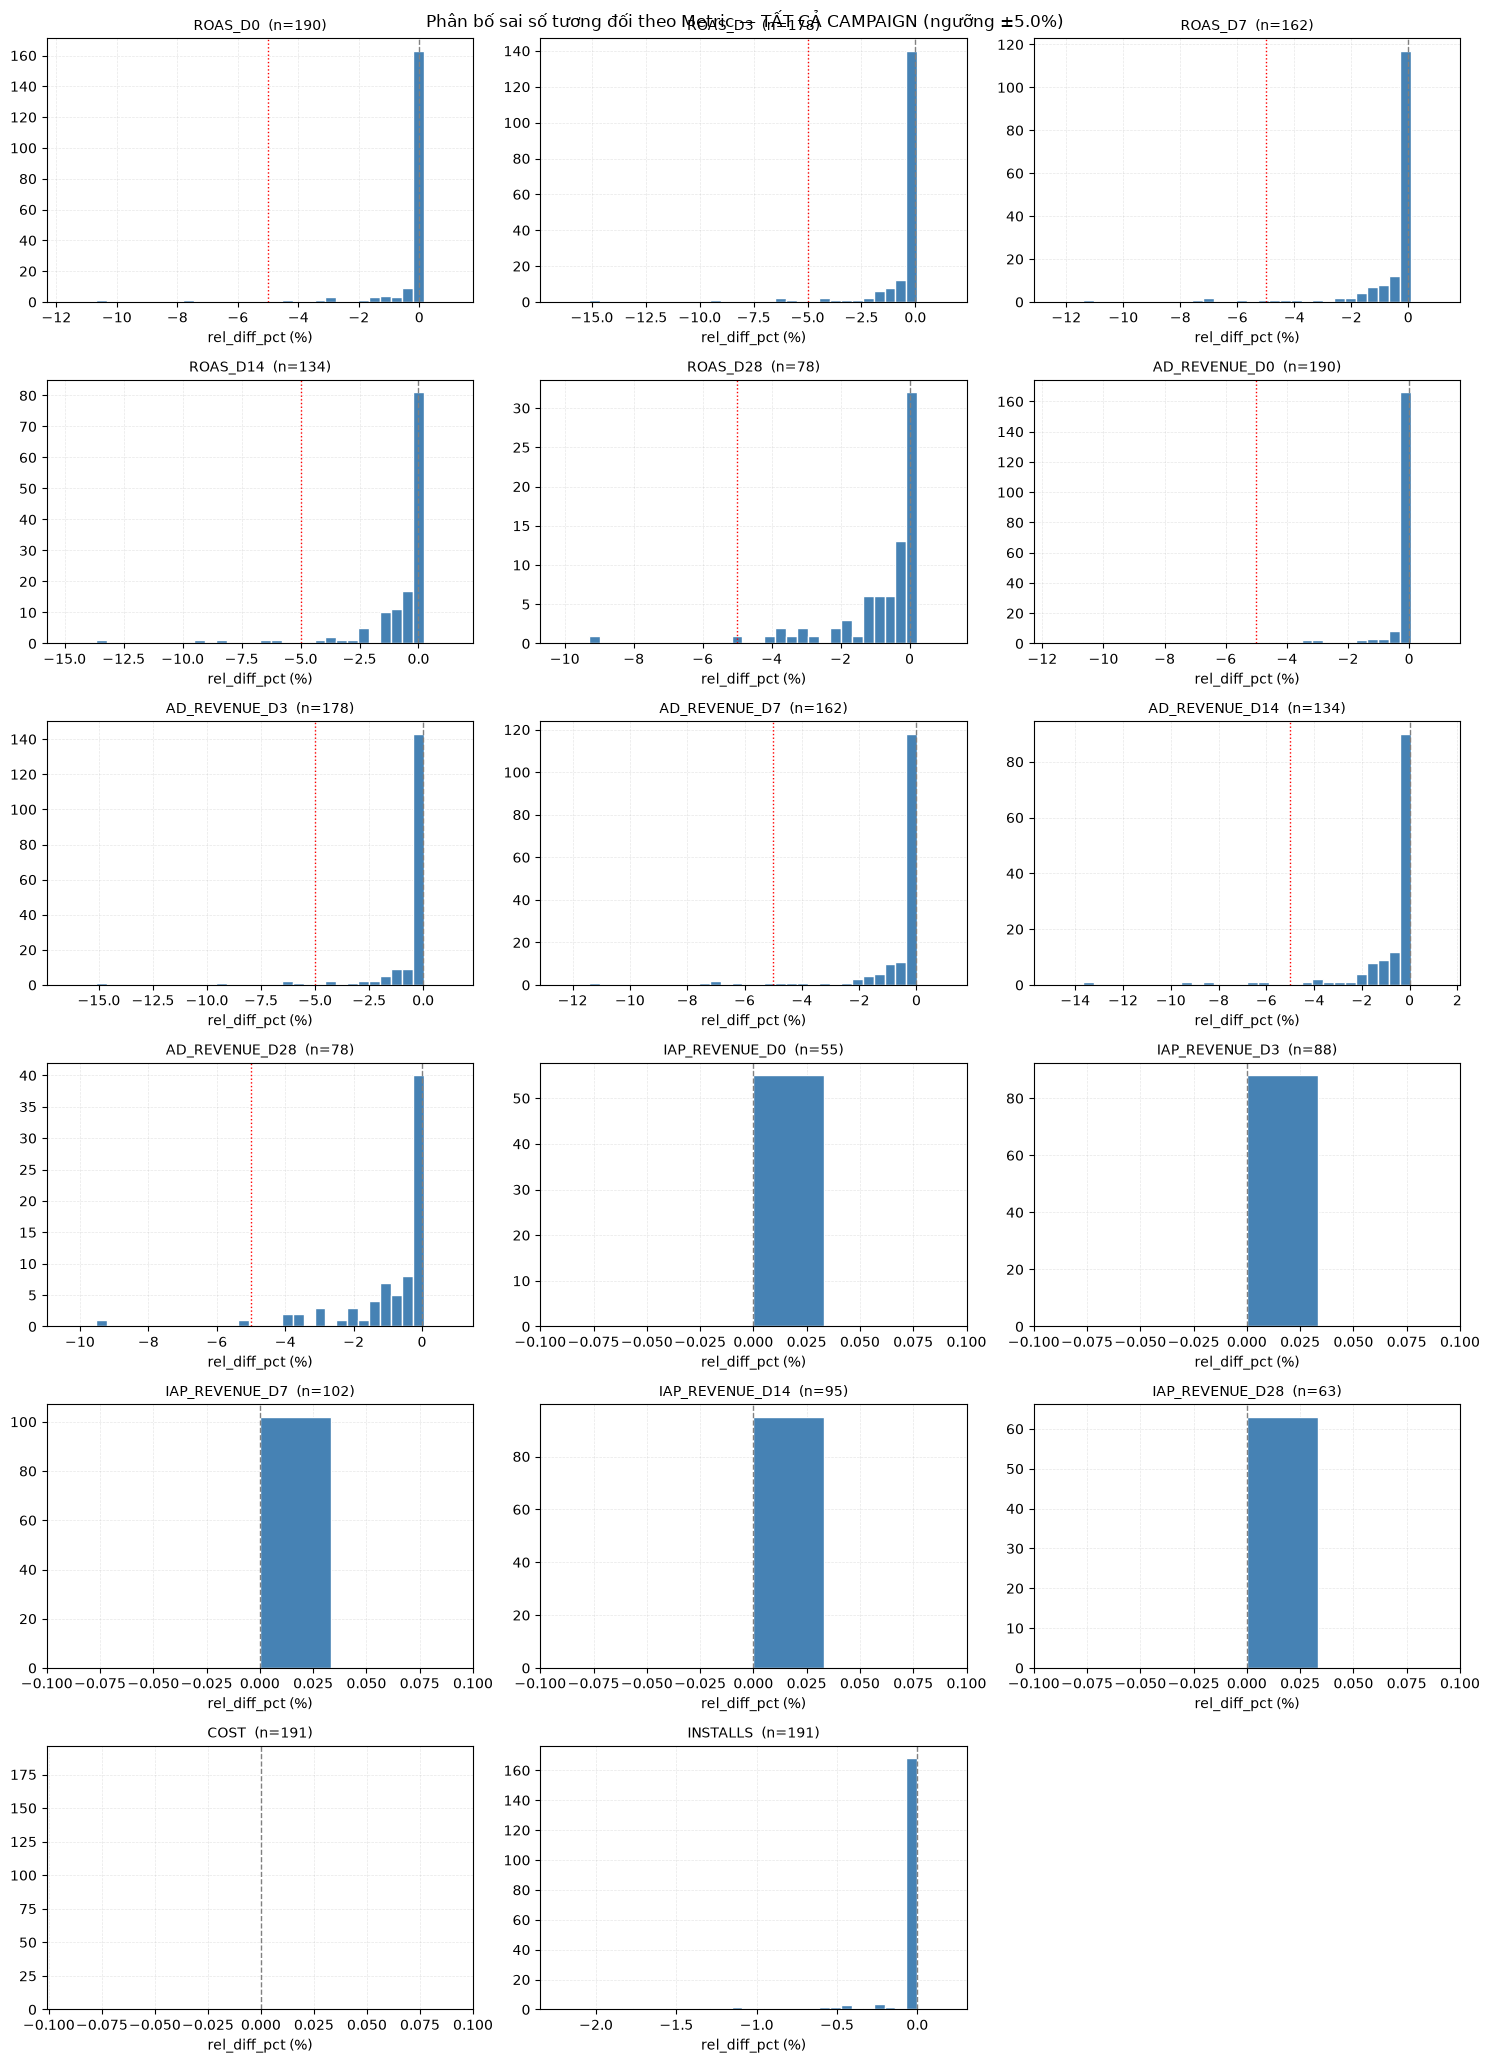

In [22]:
eda.plot_rel_diff_histogram(detail)

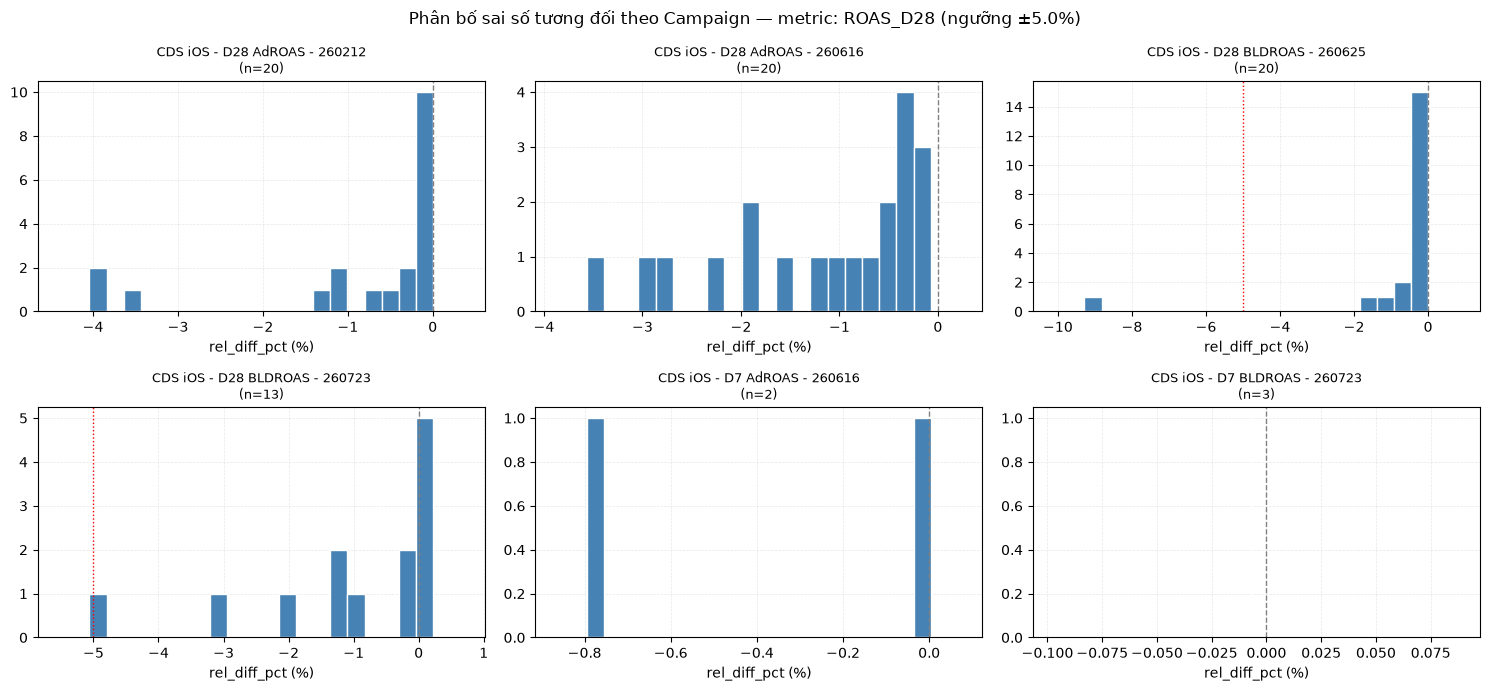

In [23]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

In [24]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

⚠️ Không tìm thấy dữ liệu hợp lệ cho campaign 'BCE Android - D28 AdROAS - 260813'. Kiểm tra lại tên campaign (VD: sorted(detail['campaign'].unique())).


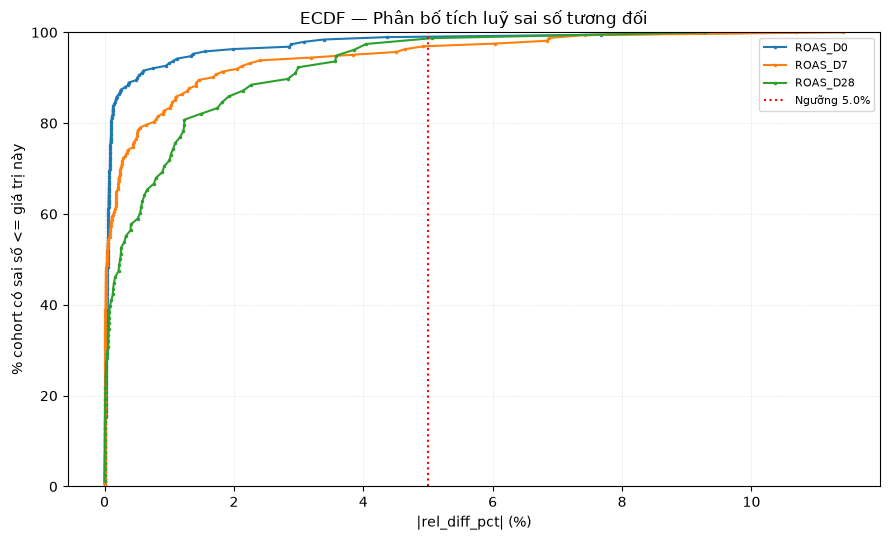

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 190                  98.9
 ROAS_D7 162                  96.9
ROAS_D28  78                  97.4


In [25]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [26]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
